In [356]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [357]:
sales = pd.read_csv("nyc-rolling-sales.csv", na_values=' -  ')

In [358]:
sales.columns

Index(['Unnamed: 0', 'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
       'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'EASE-MENT',
       'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='str')

In [359]:
sales.duplicated().sum()

np.int64(0)

In [360]:
sales.isnull().mean()

Unnamed: 0                        0.000000
BOROUGH                           0.000000
NEIGHBORHOOD                      0.000000
BUILDING CLASS CATEGORY           0.000000
TAX CLASS AT PRESENT              0.000000
BLOCK                             0.000000
LOT                               0.000000
EASE-MENT                         0.000000
BUILDING CLASS AT PRESENT         0.000000
ADDRESS                           0.000000
APARTMENT NUMBER                  0.000000
ZIP CODE                          0.000000
RESIDENTIAL UNITS                 0.000000
COMMERCIAL UNITS                  0.000000
TOTAL UNITS                       0.000000
LAND SQUARE FEET                  0.310498
GROSS SQUARE FEET                 0.326584
YEAR BUILT                        0.000000
TAX CLASS AT TIME OF SALE         0.000000
BUILDING CLASS AT TIME OF SALE    0.000000
SALE PRICE                        0.172222
SALE DATE                         0.000000
dtype: float64

In [361]:
sales.drop(columns=["Unnamed: 0"], inplace=True)

In [362]:
sales.head()

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,,...,5,0,5,1633.0,6440.0,1900,2,C2,6625000.0,2017-07-19 00:00:00
1,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,,...,28,3,31,4616.0,18690.0,1900,2,C7,NaN,2016-12-14 00:00:00
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,,...,16,1,17,2212.0,7803.0,1900,2,C7,NaN,2016-12-09 00:00:00
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,,...,10,0,10,2272.0,6794.0,1913,2,C4,3936272.0,2016-09-23 00:00:00
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,,...,6,0,6,2369.0,4615.0,1900,2,C2,8000000.0,2016-11-17 00:00:00


In [363]:
sales.dtypes

BOROUGH                             int64
NEIGHBORHOOD                          str
BUILDING CLASS CATEGORY               str
TAX CLASS AT PRESENT                  str
BLOCK                               int64
LOT                                 int64
EASE-MENT                             str
BUILDING CLASS AT PRESENT             str
ADDRESS                               str
APARTMENT NUMBER                      str
ZIP CODE                            int64
RESIDENTIAL UNITS                   int64
COMMERCIAL UNITS                    int64
TOTAL UNITS                         int64
LAND SQUARE FEET                  float64
GROSS SQUARE FEET                 float64
YEAR BUILT                          int64
TAX CLASS AT TIME OF SALE           int64
BUILDING CLASS AT TIME OF SALE        str
SALE PRICE                        float64
SALE DATE                             str
dtype: object

In [364]:
sales["SALE DATE"] = pd.to_datetime(sales["SALE DATE"])

In [365]:
sales.dtypes

BOROUGH                                    int64
NEIGHBORHOOD                                 str
BUILDING CLASS CATEGORY                      str
TAX CLASS AT PRESENT                         str
BLOCK                                      int64
LOT                                        int64
EASE-MENT                                    str
BUILDING CLASS AT PRESENT                    str
ADDRESS                                      str
APARTMENT NUMBER                             str
ZIP CODE                                   int64
RESIDENTIAL UNITS                          int64
COMMERCIAL UNITS                           int64
TOTAL UNITS                                int64
LAND SQUARE FEET                         float64
GROSS SQUARE FEET                        float64
YEAR BUILT                                 int64
TAX CLASS AT TIME OF SALE                  int64
BUILDING CLASS AT TIME OF SALE               str
SALE PRICE                               float64
SALE DATE           

In [366]:
sales["YEAR BUILT"].unique()

array([1900, 1913, 1920, 1910, 2009, 1925, 1902, 1928, 1930, 1935, 1937,
       1915, 1950, 1929, 1901, 1940, 2005,    0, 1989, 2014, 2008, 1965,
       2013, 2003, 2006, 2007, 1951, 1899, 1850, 1905, 1864, 1917, 1911,
       1983, 1926, 1963, 1960, 1889, 1898, 1939, 1938, 1927, 1909, 1958,
       1904, 1907, 1987, 1931, 1984, 1948, 2004, 1918, 1875, 2012, 1973,
       2011, 1922, 2001, 1932, 1980, 1908, 1953, 1906, 2015, 1946, 1921,
       2010, 1954, 1111, 1924, 1990, 1890, 1991, 1988, 1895, 2016, 1957,
       1986, 1966, 1998, 1870, 1923, 1969, 2017, 1968, 1934, 1956, 1982,
       1914, 1903, 1967, 1840, 1912, 1964, 1955, 1961, 1851, 2000, 1959,
       1962, 1945, 1972, 1976, 1916, 1880, 1970, 1846, 1941, 1952, 1896,
       1985, 1981, 1888, 1947, 1975, 1974, 2002, 1994, 1892, 1894, 1891,
       1996, 1997, 1949, 1999, 1800, 1979, 1971, 1977, 1942, 1978, 1826,
       1881, 1919, 1883, 1936, 1993, 1995, 1933, 1992, 1943, 1944, 1847,
       1829, 1844, 1835, 1852, 1856, 1854, 1832, 18

In [367]:
sales["YEAR BUILT"] = sales["YEAR BUILT"].replace(0, np.nan)

In [368]:
(sales["YEAR BUILT"] == 0).sum()

np.int64(0)

In [369]:
sales["SALE PRICE"].value_counts().sort_index().head(20)

SALE PRICE
0.0      10228
1.0        134
2.0          3
3.0          2
5.0          1
8.0          1
10.0       766
19.0         1
20.0         4
100.0       90
200.0        1
210.0        1
250.0        1
300.0        1
315.0        1
373.0        1
500.0       67
501.0        1
600.0        1
750.0        1
Name: count, dtype: int64

In [370]:
Q1 = sales["SALE PRICE"].quantile(0.25)
Q3 = sales["SALE PRICE"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
lower_bound

np.float64(-862500.0)

In [371]:
sales["IS TRANSFER"] = (sales["SALE PRICE"] <= 20).astype("boolean")

In [372]:
sales.head()

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,IS TRANSFER
0,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,,...,0,5,1633.0,6440.0,1900.0,2,C2,6625000.0,2017-07-19,False
1,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,,...,3,31,4616.0,18690.0,1900.0,2,C7,NaN,2016-12-14,False
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,,...,1,17,2212.0,7803.0,1900.0,2,C7,NaN,2016-12-09,False
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,,...,0,10,2272.0,6794.0,1913.0,2,C4,3936272.0,2016-09-23,False
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,,...,0,6,2369.0,4615.0,1900.0,2,C2,8000000.0,2016-11-17,False


In [373]:
((sales["LAND SQUARE FEET"].isna() == True) & (sales["GROSS SQUARE FEET"].isna() == True ) & (sales["SALE PRICE"].isna() == True)).value_counts()

False    79486
True      5062
Name: count, dtype: int64

In [374]:
((sales["LAND SQUARE FEET"].isna() == True) & (sales["GROSS SQUARE FEET"].isna() == True ) & (sales["SALE PRICE"].isna() == True)).value_counts(normalize = True)*100

False    94.012868
True      5.987132
Name: proportion, dtype: float64

In [375]:
sales["SALE PRICE"].isnull().mean()*100

np.float64(17.22216965510716)

In [376]:
sales = sales.dropna(subset=['SALE PRICE'])

In [377]:
sales["SALE PRICE"].isnull().mean()*100

np.float64(0.0)

In [378]:
sales["SALE PRICE"].isnull().sum()

np.int64(0)

In [379]:
# sales.shape

In [380]:
# sales = sales[sales["LAND SQUARE FEET"] != sales["GROSS SQUARE FEET"]]

In [381]:
sales["YEAR BUILT"].isna().mean() * 100

np.float64(7.702859102404733)

In [382]:
sales["TOTAL UNITS"] = (sales["RESIDENTIAL UNITS"] + sales["COMMERCIAL UNITS"])

In [383]:
sales["BOROUGH"].unique()

array([1, 2, 3, 4, 5])

In [384]:
borough_names = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"}

sales["BOROUGH NAME"] = sales["BOROUGH"].map(borough_names)
sales.head()

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,IS TRANSFER,BOROUGH NAME
0,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,,...,5,1633.0,6440.0,1900.0,2,C2,6625000.0,2017-07-19,False,Manhattan
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,,...,10,2272.0,6794.0,1913.0,2,C4,3936272.0,2016-09-23,False,Manhattan
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,,...,6,2369.0,4615.0,1900.0,2,C2,8000000.0,2016-11-17,False,Manhattan
6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,406,32,,C4,210 AVENUE B,,...,8,1750.0,4226.0,1920.0,2,C4,3192840.0,2016-09-23,False,Manhattan
9,1,ALPHABET CITY,08 RENTALS - ELEVATOR APARTMENTS,2,387,153,,D9,629 EAST 5TH STREET,,...,24,4489.0,18523.0,1920.0,2,D9,16232000.0,2016-11-07,False,Manhattan


In [385]:
sales.loc[sales["YEAR BUILT"] == 1111]

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,IS TRANSFER,BOROUGH NAME
957,1,CHELSEA,29 COMMERCIAL GARAGES,4,799,70,,G6,7 AVENUE,,...,0,2125.0,NaN,1111.0,4,G6,8208750.0,2017-04-21,False,Manhattan


In [386]:
sales.loc[sales["YEAR BUILT"] == 1111, "YEAR BUILT"] = np.nan

In [387]:
sales.loc[sales["YEAR BUILT"] == 1111]

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,IS TRANSFER,BOROUGH NAME


## Graph one
#### How do property sale prices vary across the five New York City boroughs?

In [388]:
non_transfer_sales = sales[sales["IS TRANSFER"] == False]

In [389]:
borough_price = (non_transfer_sales.groupby("BOROUGH NAME")["SALE PRICE"].median().sort_values(ascending=False))

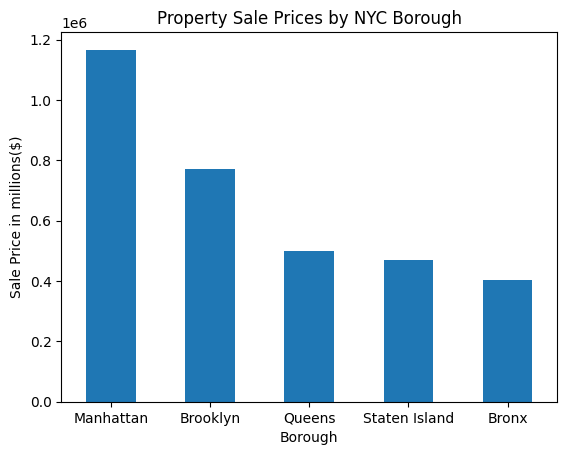

In [390]:
borough_price.plot(kind="bar")

plt.title("Property Sale Prices by NYC Borough")
plt.xlabel("Borough")
plt.ylabel("Sale Price in millions($)")
plt.xticks(rotation=0);

## Graph two
#### Which NYC neighborhoods had the highest number of property sales?

In [391]:
top_neighborhoods = (sales[sales["IS TRANSFER"] == False].groupby("NEIGHBORHOOD").size()
    .sort_values(ascending=False).head(10))

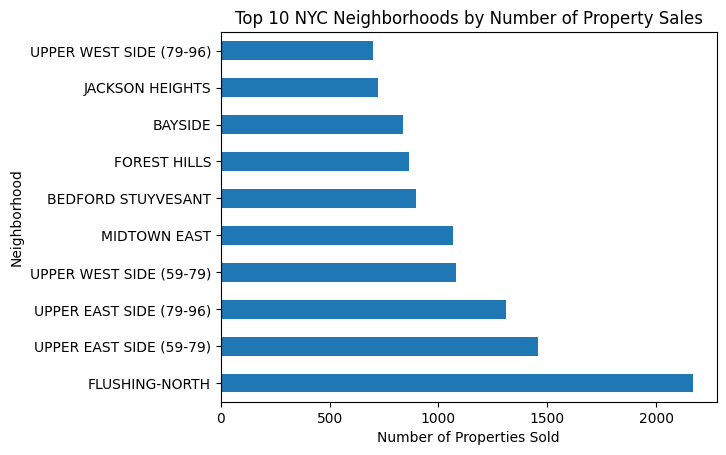

In [392]:
top_neighborhoods.plot(kind="barh")

plt.title("Top 10 NYC Neighborhoods by Number of Property Sales")
plt.xlabel("Number of Properties Sold")
plt.ylabel("Neighborhood");

## Graph three
#### Which building ages had the highest number of property sales?

In [399]:
sales["BUILDING AGE"] = sales["SALE DATE"].dt.year - sales["YEAR BUILT"]

In [400]:
age_sales = (sales[(sales["IS TRANSFER"] == False) & (sales["BUILDING AGE"].notna()) & (sales["BUILDING AGE"] >= 0)]
    .groupby("BUILDING AGE").size().sort_index())

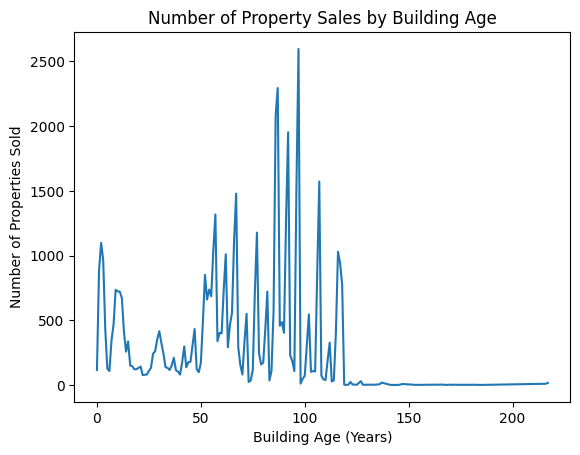

In [401]:
age_sales.plot(kind="line")

plt.title("Number of Property Sales by Building Age")
plt.xlabel("Building Age (Years)")
plt.ylabel("Number of Properties Sold");

In [402]:
print("Building age with the most sales:", age_sales.idxmax())
print("Number of properties sold:", age_sales.max())

Building age with the most sales: 97.0
Number of properties sold: 2597


## Graph four
#### How did the number of property sales change each month?

In [395]:
monthly_sales = (sales[sales["IS TRANSFER"] == False].groupby(sales["SALE DATE"].dt.to_period("M")).size())

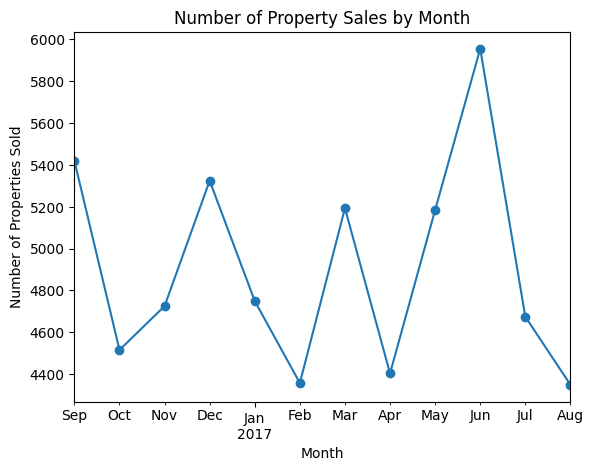

In [396]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Number of Property Sales by Month")
plt.xlabel("Month")
plt.ylabel("Number of Properties Sold");

## Graph five
#### Which type of property had more sales: residential or commercial?

In [406]:
residential = sales[(sales["RESIDENTIAL UNITS"] > 0) & (sales["COMMERCIAL UNITS"] == 0) &
    (sales["IS TRANSFER"] == False)].shape[0]

commercial = sales[(sales["COMMERCIAL UNITS"] > 0) &(sales["RESIDENTIAL UNITS"] == 0) &
    (sales["IS TRANSFER"] == False)].shape[0]

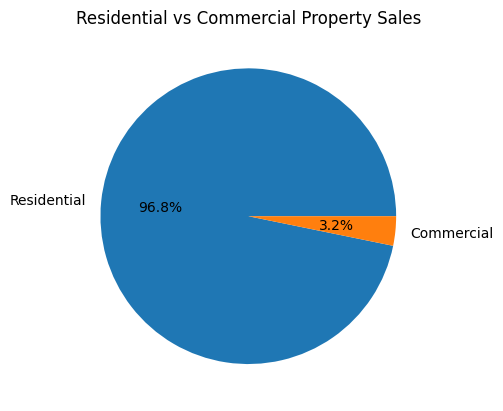

In [407]:
plt.pie([residential, commercial], labels=["Residential", "Commercial"], autopct="%1.1f%%")
plt.title("Residential vs Commercial Property Sales");

In [403]:
sales.to_csv("nyc_property_sales_cleaned.csv", index=False)